<a href="https://colab.research.google.com/github/ommestriker007/Crop_classification/blob/main/Crop_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install geemap

In [2]:
import ee
import geemap

In [3]:
ee.Authenticate()
ee.Initialize(project = "neon-feat-313910")

In [4]:
aoi = ee.FeatureCollection("projects/neon-feat-313910/assets/Sangola")

In [5]:
def add_indices(image):
  ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')

  evi = image.expression(
    '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
        'NIR': image.select('B8'),
        'RED': image.select('B4'),
        'BLUE': image.select('B2')
    }).rename('EVI')

  ndwi = image.normalizedDifference(['B3', 'B8']).rename('NDWI')

  return image.addBands(ndvi).addBands(evi).addBands(ndwi)


In [6]:
start_date = '2025-06-01'
end_date = '2025-10-30'

S2_image_collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi)
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(add_indices)
    )

print('Total images available', S2_image_collection.size().getInfo())

Total images available 7


In [7]:
sangola = S2_image_collection.median().clip(aoi)

In [8]:
Map = geemap.Map()
Map.centerObject(aoi, 10)
Map

# True Color
rgb_vis = {'bands': ['B4', 'B3', 'B2'], 'min': 55, 'max': 5175}
Map.addLayer(sangola, rgb_vis, 'True Color RGB')

# NDVI layer
ndvi_vis = {'bands': ['NDVI'], 'min': 0, 'max': 1,
            'palette': ['yellow', 'lightgreen', 'darkgreen']}
Map.addLayer(sangola, ndvi_vis, 'NDVI')

# Your AOI boundary in red
Map.addLayer(aoi, {'color': 'red'}, 'Sangola')

Map


Map(center=[17.39683113599391, 75.12645126233201], controls=(WidgetControl(options=['position', 'transparent_b…

In [9]:
print('Bands available:', sangola.bandNames().getInfo())

Bands available: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE', 'NDVI', 'EVI', 'NDWI']


In [10]:
# Class dictionary
crop_classes = {
    0: 'Sugarcane',
    1: 'Pomogranate',
    2: 'Grapes',
    3: 'Fallow/Bare Soil',
    4: 'Water Body'
}


In [11]:
# known ground truth points with their class labels

training_points = ee.FeatureCollection([

    # Class 0: Sugarcane
    ee.Feature(ee.Geometry.Point([75.2369, 17.43714]), {'class': 0}),
    ee.Feature(ee.Geometry.Point([75.2314, 17.4453]), {'class': 0}),
    ee.Feature(ee.Geometry.Point([75.5146, 17.1338]), {'class': 0}),

    # Class 1: Pomogranate
    ee.Feature(ee.Geometry.Point([75.0416, 17.3761]), {'class': 1}),
    ee.Feature(ee.Geometry.Point([75.0450, 17.3738]), {'class': 1}),
    ee.Feature(ee.Geometry.Point([75.0495, 17.3735]), {'class': 1}),

    # Class 2: Grapes
    ee.Feature(ee.Geometry.Point([75.1804, 17.4233]), {'class': 2}),
    ee.Feature(ee.Geometry.Point([75.1808, 17.4228]), {'class': 2}),
    ee.Feature(ee.Geometry.Point([75.1809, 17.4227]), {'class': 2}),

    # Class 3: Fallow/Bare Soil
    ee.Feature(ee.Geometry.Point([75.1783, 17.4246]), {'class': 3}),
    ee.Feature(ee.Geometry.Point([75.0666, 17.3535]), {'class': 3}),
    ee.Feature(ee.Geometry.Point([75.0667, 17.3534]), {'class': 3}),

    # Class 4: Water Body
    ee.Feature(ee.Geometry.Point([75.9900, 17.3014]), {'class': 4}),
    ee.Feature(ee.Geometry.Point([75.1715, 17.4828]), {'class': 4}),
    ee.Feature(ee.Geometry.Point([75.1716, 17.4827]), {'class': 4}),
])



In [12]:
# Bands/indices to use as features
feature_bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12',
                 'NDVI', 'EVI', 'NDWI']

# Extract spectral values at each training point
training_samples = sangola.select(feature_bands).sampleRegions(
    collection=training_points,
    properties=['class'],      # Keep the class label
    scale=10                   # Sentinel-2 resolution = 10m
)

# Check how many samples we have
print('Training samples:', training_samples.size().getInfo())

Training samples: 13


In [13]:
import pandas as pd

# List of properties to extract from each feature
properties_to_extract = feature_bands + ['class']

# Convert the Earth Engine FeatureCollection to a list of dictionaries
# Each dictionary will represent a feature and its selected properties
training_data_list = training_samples.map(lambda f: f.select(properties_to_extract)).getInfo()['features']

# Extract the 'properties' dictionary from each feature dictionary
data_for_df = [f['properties'] for f in training_data_list]

# Create a pandas DataFrame from the list of dictionaries
df = pd.DataFrame(data_for_df)

print(df.shape)
print(df.head())

(13, 10)
    B11   B12   B2   B3    B4    B8       EVI      NDVI      NDWI  class
0   413   218  110  246   231   827  1.072714  0.563327 -0.541472      0
1  1624  1071  408  708   800  1920  0.764818  0.411765 -0.461187      0
2  1958  1220  344  672   662  2858  1.284024  0.621065 -0.616438      1
3  2267  1705  660  950  1310  1868  0.300911  0.179293 -0.325763      1
4  2200  1455  415  679   760  2674  1.121565  0.555295 -0.593048      1


In [14]:
# Save to CSV
df.to_csv('crop_training_data.csv', index=False)
print("Saved!")


Saved!


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load data
df = pd.read_csv('crop_training_data.csv')

# Define features and target
feature_bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12',
                 'NDVI', 'EVI', 'NDWI']

X = df[feature_bands].values
y = df['class'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.50,
                                    random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5,
                                    random_state=42, stratify=None)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (6, 9), Val: (3, 9), Test: (4, 9)


In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# --- Model 1: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)  # RF doesn't need scaling
rf_acc = accuracy_score(y_val, rf.predict(X_val))

# --- Model 2: XGBoost ---
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                     use_label_encoder=False, eval_metric='mlogloss',
                     random_state=42)
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)], verbose=False)
xgb_acc = accuracy_score(y_val, xgb.predict(X_val))

# --- Model 3: SVM ---
svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm.fit(X_train_sc, y_train)  # SVM NEEDS scaled data
svm_acc = accuracy_score(y_val, svm.predict(X_val_sc))

# --- Compare ---
results = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost', 'SVM'],
    'Val Accuracy': [rf_acc, xgb_acc, svm_acc]
})
print(results.sort_values('Val Accuracy', ascending=False))


           Model  Val Accuracy
0  Random Forest      0.666667
2            SVM      0.666667
1        XGBoost      0.333333


                  precision    recall  f1-score   support

       Sugarcane       0.00      0.00      0.00         1
     Pomogranate       0.00      0.00      0.00         2
          Grapes       0.00      0.00      0.00         0
Fallow/Bare Soil       0.00      0.00      0.00         0
      Water Body       0.50      1.00      0.67         1

        accuracy                           0.25         4
       macro avg       0.10      0.20      0.13         4
    weighted avg       0.12      0.25      0.17         4



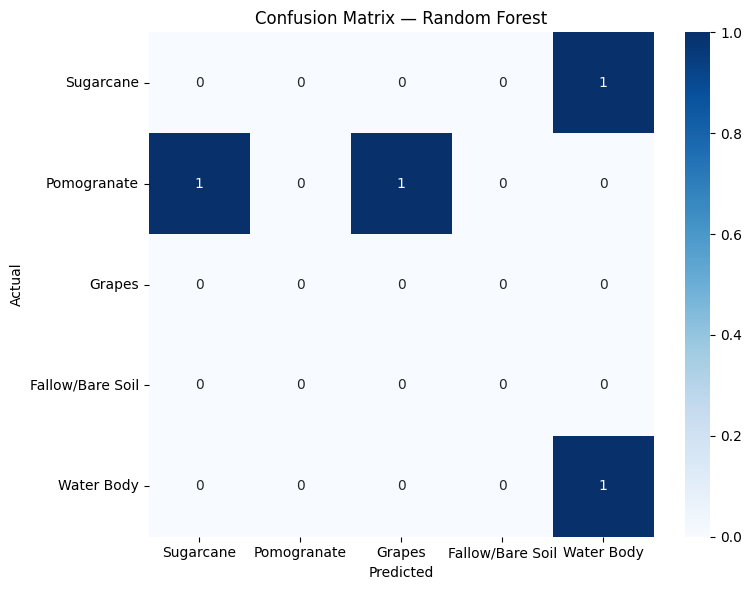

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Replace `rf` and `X_test` with your best model
best_model = rf
y_pred = best_model.predict(X_test)

# --- Classification Report ---
class_names = ['Sugarcane', 'Pomogranate', 'Grapes', 'Fallow/Bare Soil',
               'Water Body']

# Define the labels that correspond to the class_names
# This ensures that even if a class is not present in y_test or y_pred,
# the report still accounts for it in the context of class_names.
all_labels = list(range(len(class_names)))

print(classification_report(y_test, y_pred, target_names=class_names, labels=all_labels))

# --- Confusion Matrix Heatmap ---
cm = confusion_matrix(y_test, y_pred, labels=all_labels) # Used labels for consistent matrix size
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

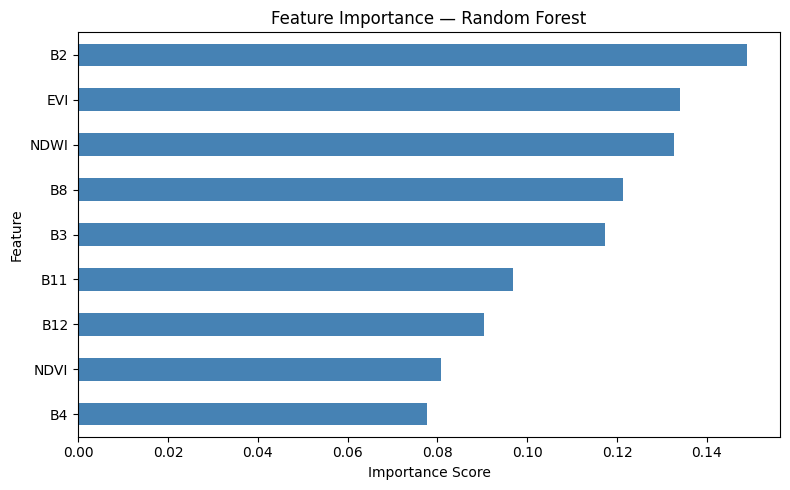

In [33]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature': feature_bands,
    'Importance': importances
}).sort_values('Importance', ascending=True)

feat_df.plot(kind='barh', x='Feature', y='Importance',
             title='Feature Importance — Random Forest',
             legend=False, color='steelblue',
             figsize=(8, 5))
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


In [35]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

# Use KFold instead of the default StratifiedKFold to avoid the error
# with very small class sizes in y_train.
# Setting n_splits to a smaller value (e.g., 3) is necessary since the training
# data is very small and some classes have only 1 sample.
cv_strategy = KFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=cv_strategy,          # Used the defined KFold strategy
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Retrain with best params
best_rf = grid_search.best_estimator_
print("Test Accuracy:", accuracy_score(y_test, best_rf.predict(X_test)))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.3333333333333333
Test Accuracy: 0.25
